In [13]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml


import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette, set_plot_colors
from autoslo.workload_execution.trace import Trace

In [ ]:
run_ids = sorted(pu.RunLocator.get_run_ids(workload_name='99_3_3', schema_name='ext'))[:-1]

dfs = []

for run_id in run_ids:
    trace = Trace(run_id)
    latencies = trace.latencies_s
    tpcds_temp_and_q_idxs = trace.tpcds_temp_and_q_idxs

    df = latencies.to_frame(name='latency_s').merge(
        tpcds_temp_and_q_idxs.to_frame(name='tpcds_template_and_query_idx'),
        left_index=True,
        right_index=True,
    )
    
    df[['tpcds_template_id','tpcds_q_idx']] = df['tpcds_template_and_query_idx'].apply(lambda x: [int(a) for a in x.split('_')]).tolist()
    df['run_id'] = run_id
    df['rpu'] = list(trace.rpu_per_cluster().values())[0]
    dfs.append(df)
full_df = pd.concat(dfs, ignore_index=True)
full_df['endpoint_name'] = full_df['rpu'].apply(str)

In [2]:
full_df

,latency_s,tpcds_template_and_query_idx,tpcds_template_id,tpcds_q_idx,run_id,rpu,endpoint_name
0,5.592404,086_003,86,3,1759156767,16,16
1,15.105115,082_001,82,1,1759156767,16,16
2,11.859022,099_001,99,1,1759156767,16,16
3,1.881556,020_002,20,2,1759156767,16,16
4,34.731367,088_001,88,1,1759156767,16,16
...,...,...,...,...,...,...,...
6232,1.238487,032_001,32,1,1759429111,4,4
6233,13.181634,085_002,85,2,1759429111,4,4
6234,35.016537,003_003,3,3,1759429111,4,4
6235,18.010481,013_003,13,3,1759429111,4,4


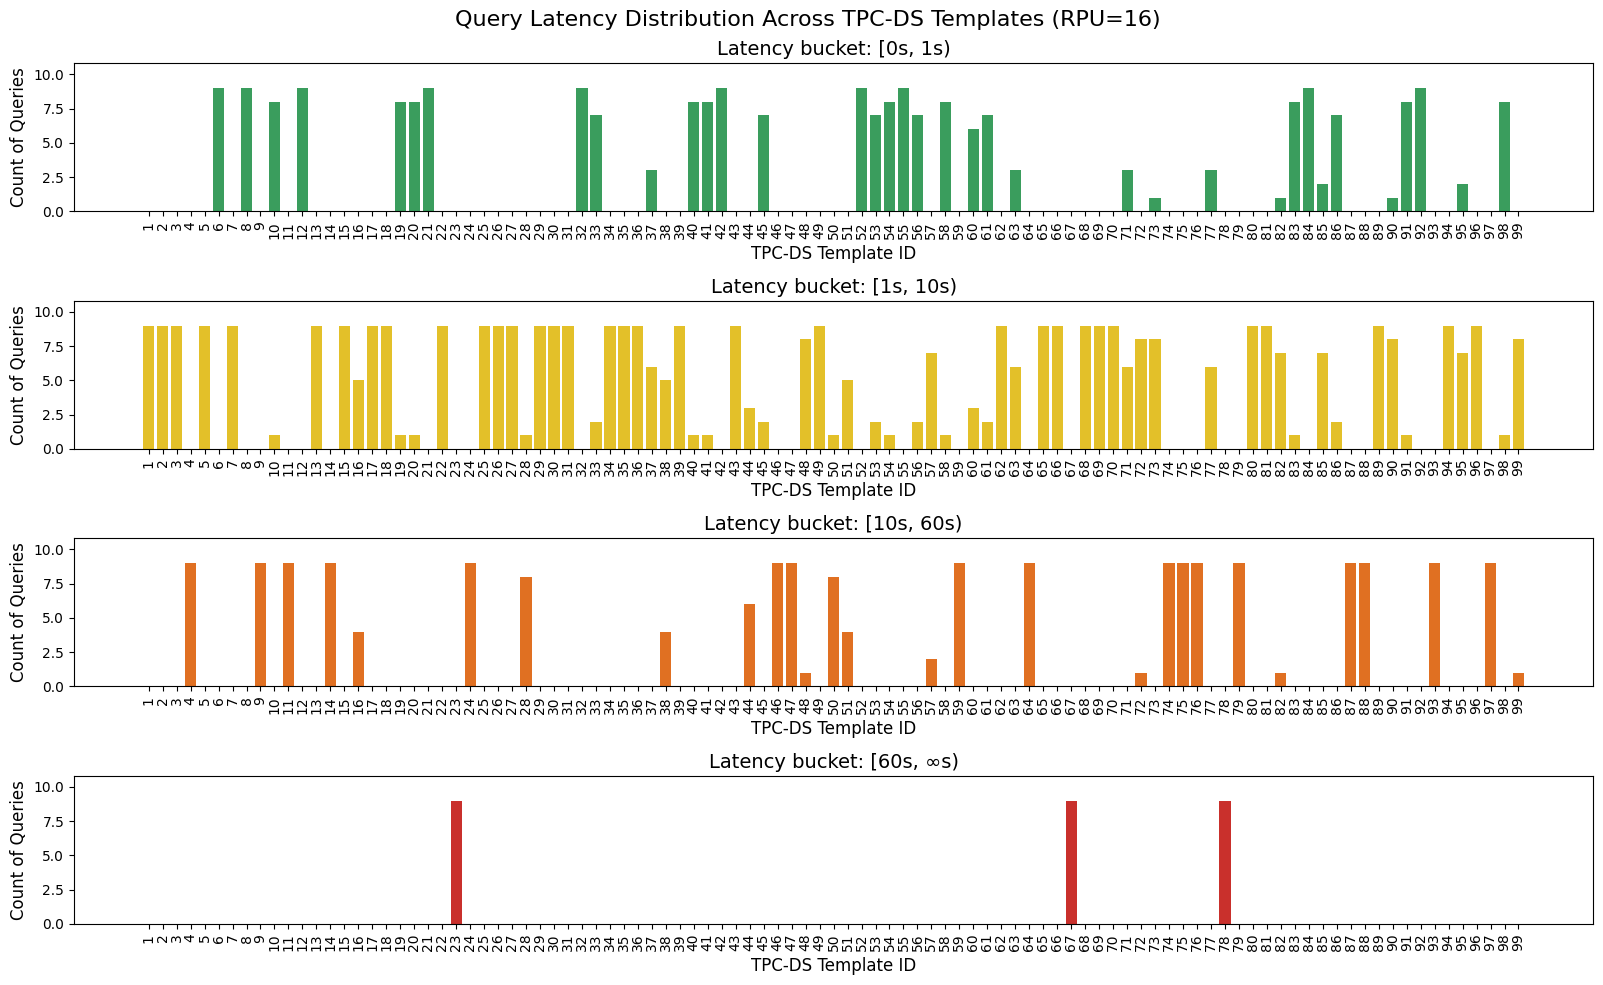

In [5]:
latency_bucket_left_edges = [0,  1, 10, 60]
reference_rpu = 16

full_df['latency_bucket_left_edge_s'] = full_df['latency_s'].apply(lambda x: max([edge for edge in latency_bucket_left_edges if edge <= x]))
full_df['latency_bucket_idx'] = full_df['latency_bucket_left_edge_s'].apply(lambda x: latency_bucket_left_edges.index(x))
sub_df = full_df[full_df['rpu'] == reference_rpu].copy()

# For each template and latency bucket, get the count of queries that fall into that bucket.
template_latency_counts = sub_df.groupby(['tpcds_template_id', 'latency_bucket_left_edge_s']).size().unstack(fill_value=0)
template_latency_counts

# Plot 4 subplots sharing an x axis. Each subplotis for a different bucket, 
# and the x axis is the template id. In each subplot, plot a bar for each 
# template, where the height of the bar is the count of queries that fall into 
# that bucket for that template. Use the same y axis limits for all subplots.

fig, ax = plt.subplots(4, 1, figsize=(16, 10), sharey=True)

bucket_colors = {
    0: Palette.dark_green,
    1: Palette.dark_yellow,
    10: Palette.dark_orange,
    60: Palette.dark_red
}

for i, bucket in enumerate(latency_bucket_left_edges):
    bucket_counts = template_latency_counts[bucket]
    ax[i].bar(bucket_counts.index, bucket_counts.values, color=bucket_colors[bucket])
    right_edge = '\u221E'
    if i < len(latency_bucket_left_edges) - 1:
        right_edge = latency_bucket_left_edges[i + 1]
    
    ax[i].set_title(f"Latency bucket: [{bucket}s, {right_edge}s)", fontsize=14)
    ax[i].set_xlabel("TPC-DS Template ID", fontsize=12)
    ax[i].set_ylabel("Count of Queries", fontsize=12)
    ax[i].set_xticks(bucket_counts.index)
    ax[i].set_xticklabels(bucket_counts.index, rotation=90)
    ax[i].set_ylim(0, template_latency_counts.values.max() * 1.2)

plt.suptitle(f"Query Latency Distribution Across TPC-DS Templates (RPU={reference_rpu})", fontsize=16)
plt.tight_layout()
plt.savefig(f"template_latency_buckets_{reference_rpu}.svg", dpi=300)
plt.show()

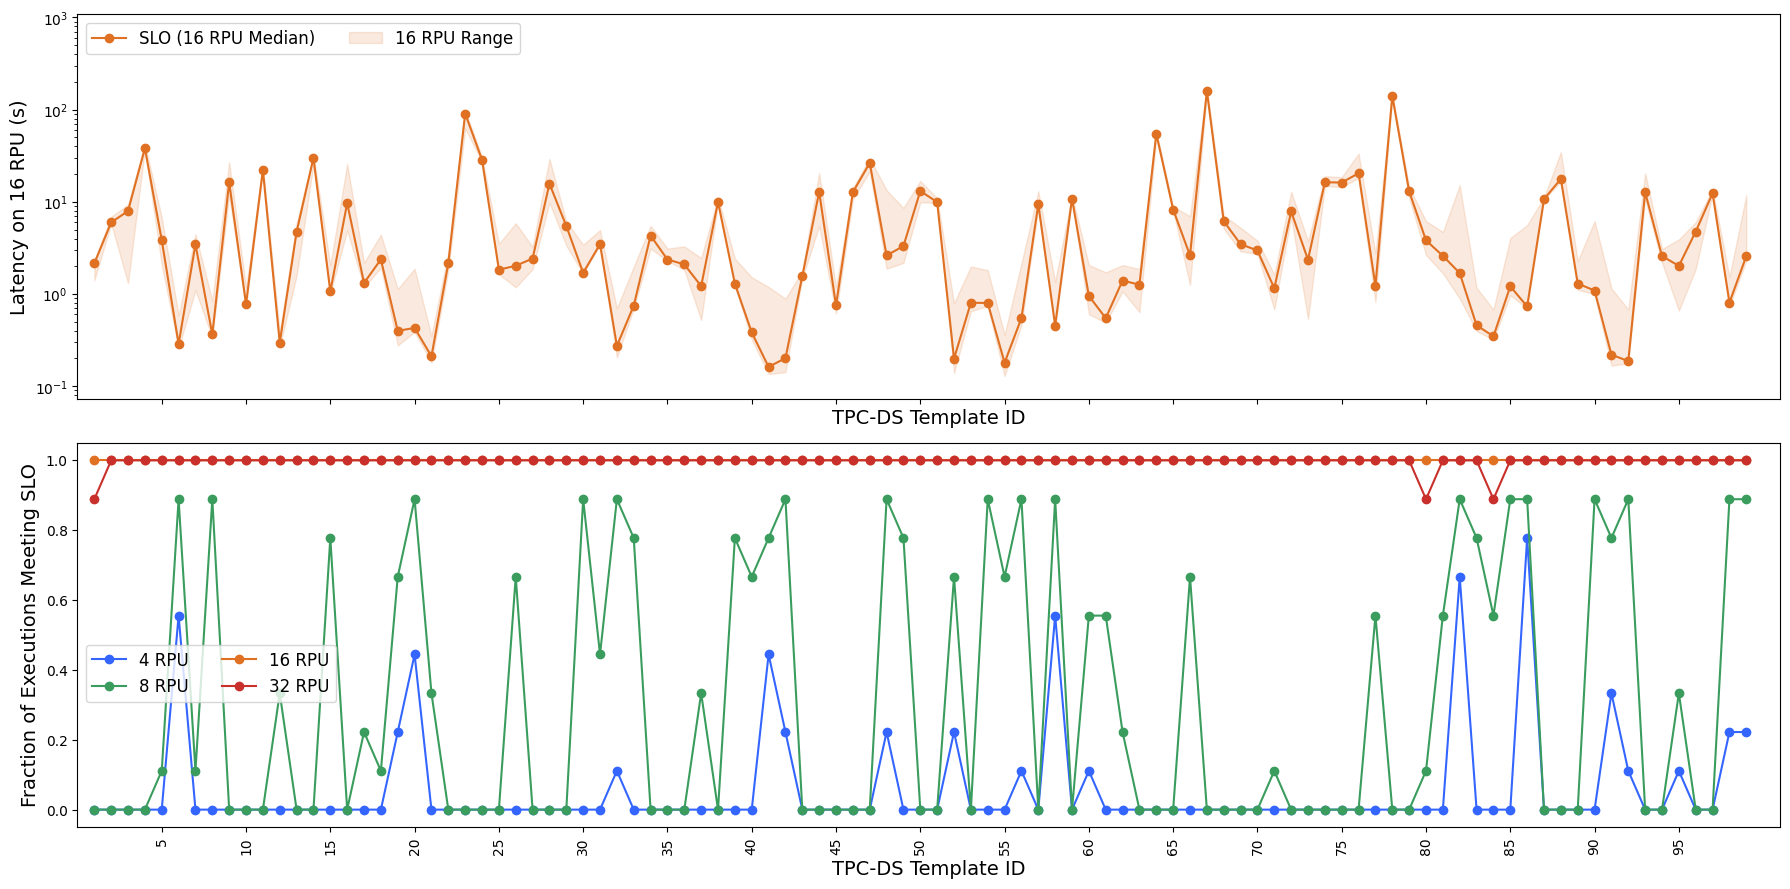

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(18, 9), sharex=True)

color_map = {
    4: Palette.dark_blue,
    8: Palette.dark_green,
    16: Palette.dark_orange,
    32: Palette.dark_red,
}

template_order = list(range(1, 100))
if True:
    ax = axs[0]
    rpu = reference_rpu
    subset = full_df[full_df["rpu"] == rpu]

    # Just plot the median, min and max per template as separate line plots.
    median_df = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .median()
        .reindex(template_order)
    )
    min_df = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .min()
        .reindex(template_order)
    )
    max_df = (
        subset.groupby("tpcds_template_id")["latency_s"]
        .max()
        .reindex(template_order)
    )

    # Treat the template ids as categorical and plot them in the order of the
    # template_order.
    x_positions = range(len(template_order))
    ax.plot(
        x_positions,
        median_df.values,
        label=f"SLO ({rpu} RPU Median)",
        color=color_map[rpu],
        marker="o",
    )
    ax.fill_between(
        x_positions,
        min_df.values,
        max_df.values,
        label=f"{rpu} RPU Range",
        color=color_map[rpu],
        alpha=0.15,
    )
    # Add a tick for every 5th template id.
    ax.set_xticks(
        [template_order.index(i) for i in template_order if i % 5 == 0]
    )
    ax.set_xticklabels([i for i in template_order if i % 5 == 0], rotation=90)
    ax.set_xlabel("TPC-DS Template ID", fontsize=14)
    ax.set_ylabel(f"Latency on {rpu} RPU (s)", fontsize=14)
    ax.set_yscale("log")

    ax.set_ylim(
        full_df["latency_s"].min() * 0.8, full_df["latency_s"].max() * 1.2
    )
    ax.set_xlim(-1, 100)

    ax.legend(
        loc="upper left",
        fontsize=12,
        title_fontsize=12,
        ncols=2,
    )

if True:
    # For each RPU value, plot the  fraction of executions of each template that
    # take less than the median latency of that template on 8 RPUs.
    ax = axs[1]
    rpu_to_fraction_below_median_8rpu = {}
    for rpu in color_map.keys():
        subset = full_df[full_df["rpu"] == rpu]
        median_8rpu = (
            full_df[full_df["rpu"] == reference_rpu]
            .groupby("tpcds_template_id")["latency_s"]
            .max()
        )
        fraction_below_median_reference_rpu = (
            subset.groupby("tpcds_template_id")
            .apply(lambda x: (x["latency_s"] <= median_8rpu[x.name]).mean(),  include_groups=False)
            .reindex(template_order)
        )
        rpu_to_fraction_below_median_8rpu[rpu] = (
            fraction_below_median_reference_rpu
        )
        ax.plot(
            range(len(template_order)),
            fraction_below_median_reference_rpu.values,
            label=f"{rpu} RPU",
            color=color_map[rpu],
            marker="o",
        )
    ax.set_xticks(
        [template_order.index(i) for i in template_order if i % 5 == 0]
    )
    ax.set_xticklabels([i for i in template_order if i % 5 == 0], rotation=90)
    ax.set_xlabel("TPC-DS Template ID", fontsize=14)
    ax.set_ylabel("Fraction of Executions Meeting SLO", fontsize=14)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(
        loc="center left",
        bbox_to_anchor=(0, 0.4),
        fontsize=12,
        title_fontsize=12,
        ncols=2,
    )


plt.tight_layout()
plt.savefig(f"slo_selection_{reference_rpu}.svg", dpi=300)
plt.show()

In [14]:
slo_dict = max_df.to_dict()
# Round to 1 ms
slo_dict = {k: round(v, 3) for k, v in slo_dict.items()}

with open(
    os.path.join(pu.get_data_path(), "generation_parameters", "slo_dict.yml"),
    "w",
) as f:
    yaml.dump(slo_dict, f)

In [23]:
# Print out distribution.
temp_and_q_idx_latency_counts = sub_df.groupby(['tpcds_template_and_query_idx', 'latency_bucket_left_edge_s']).size().unstack(fill_value=0).T
temp_and_q_idx_latency_counts   

tpcds_template_and_query_idx,001_001,001_002,001_003,002_001,002_002,002_003,003_001,003_002,003_003,004_001,...,096_003,097_001,097_002,097_003,098_001,098_002,098_003,099_001,099_002,099_003
latency_bucket_left_edge_s,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,3,2,0,0,0
1,3,3,3,3,3,3,3,3,3,0,...,3,0,0,0,0,0,1,2,3,3
10,0,0,0,0,0,0,0,0,0,3,...,0,3,3,3,0,0,0,1,0,0
60,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
out_dir = os.path.join(pu.get_data_path(), "generation_parameters", "dist_16_rpu")
os.makedirs(out_dir, exist_ok=True)

index_dict = temp_and_q_idx_latency_counts.index.to_series().reset_index(drop=True).to_dict()
with open(os.path.join(out_dir, "index_dict.yml"), "w") as f:
    yaml.dump(index_dict, f, sort_keys=True)
print(index_dict)

column_dict = temp_and_q_idx_latency_counts.columns.to_series().reset_index(drop=True).to_dict()
with open(os.path.join(out_dir, "column_dict.yml"), "w") as f:
    yaml.dump(column_dict, f, sort_keys=True)
print(column_dict)

array = temp_and_q_idx_latency_counts.values.astype(float)
with open(os.path.join(out_dir, "array.npy"), "wb") as f:
    np.save(f, array)
print(array)

{0: 0, 1: 1, 2: 10, 3: 60}
{0: '001_001', 1: '001_002', 2: '001_003', 3: '002_001', 4: '002_002', 5: '002_003', 6: '003_001', 7: '003_002', 8: '003_003', 9: '004_001', 10: '004_002', 11: '004_003', 12: '005_001', 13: '005_002', 14: '005_003', 15: '006_001', 16: '006_002', 17: '006_003', 18: '007_001', 19: '007_002', 20: '007_003', 21: '008_001', 22: '008_002', 23: '008_003', 24: '009_001', 25: '009_002', 26: '009_003', 27: '010_001', 28: '010_002', 29: '010_003', 30: '011_001', 31: '011_002', 32: '011_003', 33: '012_001', 34: '012_002', 35: '012_003', 36: '013_001', 37: '013_002', 38: '013_003', 39: '014_001', 40: '014_002', 41: '014_003', 42: '015_001', 43: '015_002', 44: '015_003', 45: '016_001', 46: '016_002', 47: '016_003', 48: '017_001', 49: '017_002', 50: '017_003', 51: '018_001', 52: '018_002', 53: '018_003', 54: '019_001', 55: '019_002', 56: '019_003', 57: '020_001', 58: '020_002', 59: '020_003', 60: '021_001', 61: '021_002', 62: '021_003', 63: '022_001', 64: '022_002', 65: '02

In [34]:
array

array([[0, 0, 0, ..., 0, 0, 0],
       [3, 3, 3, ..., 2, 3, 3],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4, 297))